# NYC Yellow Taxi Fare Prediction using Snowflake and Machine Learning

[Dataset: NYC Yellow Taxi](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page)

In [ ]:
# Install if needed:
# !pip install snowflake-connector-python python-dotenv pandas numpy scikit-learn scipy joblib matplotlib pyarrow
# !pip install xgboost

In [2]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv
import snowflake.connector
from scipy.stats import randint, loguniform

from sklearn.model_selection import train_test_split, KFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

import joblib

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
Path("models").mkdir(exist_ok=True)

## 1. Control switches

Defaults are intentionally machine-safe. Can be changed if you have powerful machine.


In [3]:
USE_FULL_DATASET = False
SAMPLE_SIZE = 500_000

RUN_XGBOOST = False
RUN_XGBOOST_TUNING = False

N_JOBS = 1
CV_SPLITS = 3
N_ITER_LIGHT_TUNING = 8

print("USE_FULL_DATASET:", USE_FULL_DATASET)
print("SAMPLE_SIZE:", SAMPLE_SIZE)
print("RUN_XGBOOST:", RUN_XGBOOST)
print("N_JOBS:", N_JOBS)

USE_FULL_DATASET: False
SAMPLE_SIZE: 500000
RUN_XGBOOST: False
N_JOBS: 1


## 2. Snowflake connection

In [4]:
load_dotenv()

required_env_vars = [
    "NYC_SNOWFLAKE_USER",
    "NYC_SNOWFLAKE_PASSWORD",
    "NYC_SNOWFLAKE_ACCOUNT",
    "NYC_SNOWFLAKE_WAREHOUSE",
    "NYC_SNOWFLAKE_DATABASE",
    "NYC_SNOWFLAKE_SCHEMA",
    "NYC_SNOWFLAKE_ROLE",
]

missing_vars = [var for var in required_env_vars if not os.getenv(var)]
if missing_vars:
    raise ValueError(f"Missing these .env variables: {missing_vars}")

SF_DATABASE = os.getenv("NYC_SNOWFLAKE_DATABASE")
SF_SCHEMA = os.getenv("NYC_SNOWFLAKE_SCHEMA")
FQ_SCHEMA = f"{SF_DATABASE}.{SF_SCHEMA}"

print("Database:", SF_DATABASE)
print("Schema:", SF_SCHEMA)
print("Fully qualified schema:", FQ_SCHEMA)

Database: NYC
Schema: PUBLIC
Fully qualified schema: NYC.PUBLIC


In [5]:
def get_snowflake_connection():
    """Create Snowflake connection using NYC project environment variables."""
    return snowflake.connector.connect(
        user=os.getenv("NYC_SNOWFLAKE_USER"),
        password=os.getenv("NYC_SNOWFLAKE_PASSWORD"),
        account=os.getenv("NYC_SNOWFLAKE_ACCOUNT"),
        warehouse=os.getenv("NYC_SNOWFLAKE_WAREHOUSE"),
        database=os.getenv("NYC_SNOWFLAKE_DATABASE"),
        schema=os.getenv("NYC_SNOWFLAKE_SCHEMA"),
        role=os.getenv("NYC_SNOWFLAKE_ROLE"),
    )


def run_sql(query, return_df=True):
    """Run SQL in Snowflake and optionally return results as a pandas DataFrame."""
    conn = get_snowflake_connection()
    try:
        with conn.cursor() as cur:
            cur.execute(query)
            if not return_df or cur.description is None:
                return None
            rows = cur.fetchall()
            columns = [desc[0] for desc in cur.description]
            return pd.DataFrame(rows, columns=columns)
    finally:
        conn.close()


def show_sql_result(query):
    return run_sql(query, return_df=True)

In [6]:
connection_test_query = """
SELECT
    CURRENT_USER() AS current_user,
    CURRENT_ROLE() AS current_role,
    CURRENT_DATABASE() AS current_database,
    CURRENT_SCHEMA() AS current_schema,
    CURRENT_WAREHOUSE() AS current_warehouse;
"""
show_sql_result(connection_test_query)

,CURRENT_USER,CURRENT_ROLE,CURRENT_DATABASE,CURRENT_SCHEMA,CURRENT_WAREHOUSE
0,ZG,ACCOUNTADMIN,NYC,PUBLIC,COMPUTE_WH


## 3. Check monthly source tables

In [7]:
monthly_count_query = f"""
SELECT 'NYC_JAN' AS table_name, COUNT(*) AS row_count FROM {FQ_SCHEMA}.NYC_JAN
UNION ALL
SELECT 'NYC_FEB' AS table_name, COUNT(*) AS row_count FROM {FQ_SCHEMA}.NYC_FEB
UNION ALL
SELECT 'NYC_MARCH' AS table_name, COUNT(*) AS row_count FROM {FQ_SCHEMA}.NYC_MARCH
UNION ALL
SELECT 'NYC_APRIL' AS table_name, COUNT(*) AS row_count FROM {FQ_SCHEMA}.NYC_APRIL
ORDER BY table_name;
"""
monthly_counts = show_sql_result(monthly_count_query)
monthly_counts

,TABLE_NAME,ROW_COUNT
0,NYC_APRIL,3800664
1,NYC_FEB,3399866
2,NYC_JAN,3724889
3,NYC_MARCH,3952451


In [8]:
print(f"Total raw rows across 4 months: {monthly_counts['ROW_COUNT'].sum():,}")

Total raw rows across 4 months: 14,877,870


In [9]:
schema_check_query = f"""
SELECT 
    table_name,
    column_name,
    ordinal_position,
    data_type
FROM {SF_DATABASE}.information_schema.columns
WHERE table_schema = '{SF_SCHEMA}'
  AND table_name IN ('NYC_JAN', 'NYC_FEB', 'NYC_MARCH', 'NYC_APRIL')
ORDER BY table_name, ordinal_position;
"""
schema_check = show_sql_result(schema_check_query)
schema_check.head(100)

,TABLE_NAME,COLUMN_NAME,ORDINAL_POSITION,DATA_TYPE
0,NYC_APRIL,VARIANT_COL,1,VARIANT
1,NYC_FEB,VARIANT_COL,1,VARIANT
2,NYC_JAN,VARIANT_COL,1,VARIANT
3,NYC_MARCH,VARIANT_COL,1,VARIANT


## 4. Combine monthly tables and standardize column names

In [10]:
actual_columns_query = f"""
SELECT
    table_name,
    ordinal_position,
    column_name,
    data_type
FROM {SF_DATABASE}.information_schema.columns
WHERE table_schema = '{SF_SCHEMA}'
  AND table_name = 'NYC_JAN'
ORDER BY ordinal_position;
"""

actual_columns = show_sql_result(actual_columns_query)
actual_columns

,TABLE_NAME,ORDINAL_POSITION,COLUMN_NAME,DATA_TYPE
0,NYC_JAN,1,VARIANT_COL,VARIANT


In [11]:
print(actual_columns["COLUMN_NAME"].tolist())

['VARIANT_COL']


In [12]:
create_raw_query = f"""
CREATE OR REPLACE TABLE {FQ_SCHEMA}.NYC_TAXI_RAW AS

SELECT
    VARIANT_COL:"VendorID"::INT AS vendor_id,
    TO_TIMESTAMP_NTZ(VARIANT_COL:"tpep_pickup_datetime"::NUMBER / 1000000) AS pickup_datetime,
    TO_TIMESTAMP_NTZ(VARIANT_COL:"tpep_dropoff_datetime"::NUMBER / 1000000) AS dropoff_datetime,
    VARIANT_COL:"passenger_count"::FLOAT AS passenger_count,
    VARIANT_COL:"trip_distance"::FLOAT AS trip_distance,
    VARIANT_COL:"RatecodeID"::FLOAT AS ratecode_id,
    VARIANT_COL:"store_and_fwd_flag"::STRING AS store_and_fwd_flag,
    VARIANT_COL:"PULocationID"::INT AS pu_location_id,
    VARIANT_COL:"DOLocationID"::INT AS do_location_id,
    VARIANT_COL:"payment_type"::INT AS payment_type,
    VARIANT_COL:"fare_amount"::FLOAT AS fare_amount,
    VARIANT_COL:"extra"::FLOAT AS extra,
    VARIANT_COL:"mta_tax"::FLOAT AS mta_tax,
    VARIANT_COL:"tip_amount"::FLOAT AS tip_amount,
    VARIANT_COL:"tolls_amount"::FLOAT AS tolls_amount,
    VARIANT_COL:"improvement_surcharge"::FLOAT AS improvement_surcharge,
    VARIANT_COL:"total_amount"::FLOAT AS total_amount,
    VARIANT_COL:"congestion_surcharge"::FLOAT AS congestion_surcharge,
    VARIANT_COL:"Airport_fee"::FLOAT AS airport_fee,
    VARIANT_COL:"cbd_congestion_fee"::FLOAT AS cbd_congestion_fee,
    '2026-01' AS data_month
FROM {FQ_SCHEMA}.NYC_JAN

UNION ALL

SELECT
    VARIANT_COL:"VendorID"::INT AS vendor_id,
    TO_TIMESTAMP_NTZ(VARIANT_COL:"tpep_pickup_datetime"::NUMBER / 1000000) AS pickup_datetime,
    TO_TIMESTAMP_NTZ(VARIANT_COL:"tpep_dropoff_datetime"::NUMBER / 1000000) AS dropoff_datetime,
    VARIANT_COL:"passenger_count"::FLOAT AS passenger_count,
    VARIANT_COL:"trip_distance"::FLOAT AS trip_distance,
    VARIANT_COL:"RatecodeID"::FLOAT AS ratecode_id,
    VARIANT_COL:"store_and_fwd_flag"::STRING AS store_and_fwd_flag,
    VARIANT_COL:"PULocationID"::INT AS pu_location_id,
    VARIANT_COL:"DOLocationID"::INT AS do_location_id,
    VARIANT_COL:"payment_type"::INT AS payment_type,
    VARIANT_COL:"fare_amount"::FLOAT AS fare_amount,
    VARIANT_COL:"extra"::FLOAT AS extra,
    VARIANT_COL:"mta_tax"::FLOAT AS mta_tax,
    VARIANT_COL:"tip_amount"::FLOAT AS tip_amount,
    VARIANT_COL:"tolls_amount"::FLOAT AS tolls_amount,
    VARIANT_COL:"improvement_surcharge"::FLOAT AS improvement_surcharge,
    VARIANT_COL:"total_amount"::FLOAT AS total_amount,
    VARIANT_COL:"congestion_surcharge"::FLOAT AS congestion_surcharge,
    VARIANT_COL:"Airport_fee"::FLOAT AS airport_fee,
    VARIANT_COL:"cbd_congestion_fee"::FLOAT AS cbd_congestion_fee,
    '2026-02' AS data_month
FROM {FQ_SCHEMA}.NYC_FEB

UNION ALL

SELECT
    VARIANT_COL:"VendorID"::INT AS vendor_id,
    TO_TIMESTAMP_NTZ(VARIANT_COL:"tpep_pickup_datetime"::NUMBER / 1000000) AS pickup_datetime,
    TO_TIMESTAMP_NTZ(VARIANT_COL:"tpep_dropoff_datetime"::NUMBER / 1000000) AS dropoff_datetime,
    VARIANT_COL:"passenger_count"::FLOAT AS passenger_count,
    VARIANT_COL:"trip_distance"::FLOAT AS trip_distance,
    VARIANT_COL:"RatecodeID"::FLOAT AS ratecode_id,
    VARIANT_COL:"store_and_fwd_flag"::STRING AS store_and_fwd_flag,
    VARIANT_COL:"PULocationID"::INT AS pu_location_id,
    VARIANT_COL:"DOLocationID"::INT AS do_location_id,
    VARIANT_COL:"payment_type"::INT AS payment_type,
    VARIANT_COL:"fare_amount"::FLOAT AS fare_amount,
    VARIANT_COL:"extra"::FLOAT AS extra,
    VARIANT_COL:"mta_tax"::FLOAT AS mta_tax,
    VARIANT_COL:"tip_amount"::FLOAT AS tip_amount,
    VARIANT_COL:"tolls_amount"::FLOAT AS tolls_amount,
    VARIANT_COL:"improvement_surcharge"::FLOAT AS improvement_surcharge,
    VARIANT_COL:"total_amount"::FLOAT AS total_amount,
    VARIANT_COL:"congestion_surcharge"::FLOAT AS congestion_surcharge,
    VARIANT_COL:"Airport_fee"::FLOAT AS airport_fee,
    VARIANT_COL:"cbd_congestion_fee"::FLOAT AS cbd_congestion_fee,
    '2026-03' AS data_month
FROM {FQ_SCHEMA}.NYC_MARCH

UNION ALL

SELECT
    VARIANT_COL:"VendorID"::INT AS vendor_id,
    TO_TIMESTAMP_NTZ(VARIANT_COL:"tpep_pickup_datetime"::NUMBER / 1000000) AS pickup_datetime,
    TO_TIMESTAMP_NTZ(VARIANT_COL:"tpep_dropoff_datetime"::NUMBER / 1000000) AS dropoff_datetime,
    VARIANT_COL:"passenger_count"::FLOAT AS passenger_count,
    VARIANT_COL:"trip_distance"::FLOAT AS trip_distance,
    VARIANT_COL:"RatecodeID"::FLOAT AS ratecode_id,
    VARIANT_COL:"store_and_fwd_flag"::STRING AS store_and_fwd_flag,
    VARIANT_COL:"PULocationID"::INT AS pu_location_id,
    VARIANT_COL:"DOLocationID"::INT AS do_location_id,
    VARIANT_COL:"payment_type"::INT AS payment_type,
    VARIANT_COL:"fare_amount"::FLOAT AS fare_amount,
    VARIANT_COL:"extra"::FLOAT AS extra,
    VARIANT_COL:"mta_tax"::FLOAT AS mta_tax,
    VARIANT_COL:"tip_amount"::FLOAT AS tip_amount,
    VARIANT_COL:"tolls_amount"::FLOAT AS tolls_amount,
    VARIANT_COL:"improvement_surcharge"::FLOAT AS improvement_surcharge,
    VARIANT_COL:"total_amount"::FLOAT AS total_amount,
    VARIANT_COL:"congestion_surcharge"::FLOAT AS congestion_surcharge,
    VARIANT_COL:"Airport_fee"::FLOAT AS airport_fee,
    VARIANT_COL:"cbd_congestion_fee"::FLOAT AS cbd_congestion_fee,
    '2026-04' AS data_month
FROM {FQ_SCHEMA}.NYC_APRIL;
"""

run_sql(create_raw_query, return_df=False)
print("Created table: NYC_TAXI_RAW")

Created table: NYC_TAXI_RAW


In [13]:
check_raw_query = f"""
SELECT
    vendor_id,
    pickup_datetime,
    dropoff_datetime,
    passenger_count,
    trip_distance,
    ratecode_id,
    pu_location_id,
    do_location_id,
    payment_type,
    fare_amount,
    data_month
FROM {FQ_SCHEMA}.NYC_TAXI_RAW
LIMIT 5;
"""

show_sql_result(check_raw_query)

,VENDOR_ID,PICKUP_DATETIME,DROPOFF_DATETIME,PASSENGER_COUNT,TRIP_DISTANCE,RATECODE_ID,PU_LOCATION_ID,DO_LOCATION_ID,PAYMENT_TYPE,FARE_AMOUNT,DATA_MONTH
0,2,2026-01-29 21:16:07,2026-01-29 21:26:28,1.0,1.19,1.0,107,161,1,10.7,2026-01
1,2,2026-01-29 21:21:43,2026-01-29 21:35:46,1.0,2.33,1.0,236,161,1,15.6,2026-01
2,2,2026-01-29 21:46:00,2026-01-29 22:02:24,2.0,4.59,1.0,144,140,1,22.6,2026-01
3,2,2026-01-29 21:05:39,2026-01-29 21:11:45,1.0,0.56,1.0,237,141,1,7.2,2026-01
4,2,2026-01-29 21:12:21,2026-01-29 21:24:05,1.0,0.97,1.0,90,186,1,11.4,2026-01


In [14]:
date_check_query = f"""
SELECT
    MIN(pickup_datetime) AS min_pickup,
    MAX(pickup_datetime) AS max_pickup,
    MIN(dropoff_datetime) AS min_dropoff,
    MAX(dropoff_datetime) AS max_dropoff
FROM {FQ_SCHEMA}.NYC_TAXI_RAW;
"""

show_sql_result(date_check_query)

,MIN_PICKUP,MAX_PICKUP,MIN_DROPOFF,MAX_DROPOFF
0,2001-01-01 09:23:58,2026-05-01 00:01:28,2001-01-01 16:09:38,2026-05-02 12:06:09


In [15]:
date_outlier_query = f"""
SELECT
    COUNT(*) AS total_rows,

    COUNT_IF(pickup_datetime < '2026-01-01') AS pickup_before_2026,
    COUNT_IF(pickup_datetime >= '2026-05-01') AS pickup_after_april,

    COUNT_IF(dropoff_datetime < '2026-01-01') AS dropoff_before_2026,
    COUNT_IF(dropoff_datetime >= '2026-05-03') AS dropoff_after_may_2

FROM {FQ_SCHEMA}.NYC_TAXI_RAW;
"""

show_sql_result(date_outlier_query)

,TOTAL_ROWS,PICKUP_BEFORE_2026,PICKUP_AFTER_APRIL,DROPOFF_BEFORE_2026,DROPOFF_AFTER_MAY_2
0,14877870,12,1,8,0


## 5. Data quality checks before creating ML table

In [16]:
missing_values_query = f"""
SELECT
    COUNT(*) AS total_rows,

    COUNT_IF(vendor_id IS NULL) AS missing_vendor_id,
    COUNT_IF(pickup_datetime IS NULL) AS missing_pickup_datetime,
    COUNT_IF(dropoff_datetime IS NULL) AS missing_dropoff_datetime,
    COUNT_IF(passenger_count IS NULL) AS missing_passenger_count,
    COUNT_IF(trip_distance IS NULL) AS missing_trip_distance,
    COUNT_IF(ratecode_id IS NULL) AS missing_ratecode_id,
    COUNT_IF(pu_location_id IS NULL) AS missing_pu_location_id,
    COUNT_IF(do_location_id IS NULL) AS missing_do_location_id,
    COUNT_IF(payment_type IS NULL) AS missing_payment_type,
    COUNT_IF(fare_amount IS NULL) AS missing_fare_amount

FROM {FQ_SCHEMA}.NYC_TAXI_RAW;
"""

show_sql_result(missing_values_query)

,TOTAL_ROWS,MISSING_VENDOR_ID,MISSING_PICKUP_DATETIME,MISSING_DROPOFF_DATETIME,MISSING_PASSENGER_COUNT,MISSING_TRIP_DISTANCE,MISSING_RATECODE_ID,MISSING_PU_LOCATION_ID,MISSING_DO_LOCATION_ID,MISSING_PAYMENT_TYPE,MISSING_FARE_AMOUNT
0,14877870,0,0,0,3856909,0,3856909,0,0,0,0


In [17]:
invalid_values_query = f"""
SELECT
    COUNT(*) AS total_rows,

    COUNT_IF(fare_amount <= 0) AS fare_le_0,
    COUNT_IF(fare_amount > 300) AS fare_gt_300,

    COUNT_IF(trip_distance <= 0) AS distance_le_0,
    COUNT_IF(trip_distance > 100) AS distance_gt_100,

    COUNT_IF(DATEDIFF('minute', pickup_datetime, dropoff_datetime) <= 0) AS duration_le_0,
    COUNT_IF(DATEDIFF('minute', pickup_datetime, dropoff_datetime) > 240) AS duration_gt_240,

    COUNT_IF(passenger_count <= 0) AS passenger_le_0,
    COUNT_IF(passenger_count > 6) AS passenger_gt_6,

    COUNT_IF(pickup_datetime < '2026-01-01') AS pickup_before_2026,
    COUNT_IF(pickup_datetime >= '2026-05-01') AS pickup_after_april,
    COUNT_IF(dropoff_datetime < '2026-01-01') AS dropoff_before_2026,
    COUNT_IF(dropoff_datetime >= '2026-05-03') AS dropoff_after_may_2

FROM {FQ_SCHEMA}.NYC_TAXI_RAW;
"""

show_sql_result(invalid_values_query)

,TOTAL_ROWS,FARE_LE_0,FARE_GT_300,DISTANCE_LE_0,DISTANCE_GT_100,DURATION_LE_0,DURATION_GT_240,PASSENGER_LE_0,PASSENGER_GT_6,PICKUP_BEFORE_2026,PICKUP_AFTER_APRIL,DROPOFF_BEFORE_2026,DROPOFF_AFTER_MAY_2
0,14877870,111594,1768,463348,631,263722,4883,52330,18,12,1,8,0


## 6. Create ML-ready table

This version includes date filters because we found a few dirty datetime outliers.

Leakage columns are intentionally excluded from the ML table.

In [18]:
create_ml_ready_query = f"""
CREATE OR REPLACE TABLE {FQ_SCHEMA}.NYC_TAXI_ML_READY AS

SELECT
    -- target
    fare_amount,

    -- numerical predictors
    trip_distance,
    DATEDIFF('minute', pickup_datetime, dropoff_datetime) AS trip_duration_minutes,
    passenger_count,

    -- categorical predictors
    vendor_id,
    ratecode_id,
    pu_location_id,
    do_location_id,
    payment_type,

    -- time-based predictors
    EXTRACT(hour FROM pickup_datetime) AS pickup_hour,
    DAYOFWEEKISO(pickup_datetime) AS pickup_day_of_week,
    EXTRACT(month FROM pickup_datetime) AS pickup_month,

    CASE
        WHEN DAYOFWEEKISO(pickup_datetime) IN (6, 7) THEN 1
        ELSE 0
    END AS is_weekend,

    data_month

FROM {FQ_SCHEMA}.NYC_TAXI_RAW

WHERE fare_amount BETWEEN 2.5 AND 300
  AND trip_distance BETWEEN 0.1 AND 100
  AND DATEDIFF('minute', pickup_datetime, dropoff_datetime) BETWEEN 1 AND 240
  AND passenger_count BETWEEN 1 AND 6
  AND passenger_count IS NOT NULL
  AND ratecode_id IS NOT NULL
  AND pickup_datetime IS NOT NULL
  AND dropoff_datetime IS NOT NULL

  -- date filters remove a tiny number of dirty/outlier rows
  AND pickup_datetime >= '2026-01-01'
  AND pickup_datetime < '2026-05-01'
  AND dropoff_datetime >= '2026-01-01'
  AND dropoff_datetime < '2026-05-03';
"""

run_sql(create_ml_ready_query, return_df=False)
print("Created table: NYC_TAXI_ML_READY")

Created table: NYC_TAXI_ML_READY


In [19]:
ml_ready_summary_query = f"""
SELECT
    COUNT(*) AS clean_rows,

    MIN(fare_amount) AS min_fare,
    MAX(fare_amount) AS max_fare,
    AVG(fare_amount) AS avg_fare,

    MIN(trip_distance) AS min_distance,
    MAX(trip_distance) AS max_distance,
    AVG(trip_distance) AS avg_distance,

    MIN(trip_duration_minutes) AS min_duration,
    MAX(trip_duration_minutes) AS max_duration,
    AVG(trip_duration_minutes) AS avg_duration,

    MIN(pickup_month) AS min_pickup_month,
    MAX(pickup_month) AS max_pickup_month

FROM {FQ_SCHEMA}.NYC_TAXI_ML_READY;
"""

show_sql_result(ml_ready_summary_query)

,CLEAN_ROWS,MIN_FARE,MAX_FARE,AVG_FARE,MIN_DISTANCE,MAX_DISTANCE,AVG_DISTANCE,MIN_DURATION,MAX_DURATION,AVG_DURATION,MIN_PICKUP_MONTH,MAX_PICKUP_MONTH
0,10545235,2.5,300.0,19.574414,0.1,97.4,3.446375,1,240,17.502948,1,4


In [20]:
clean_monthly_query = f"""
SELECT
    data_month,
    COUNT(*) AS clean_rows
FROM {FQ_SCHEMA}.NYC_TAXI_ML_READY
GROUP BY data_month
ORDER BY data_month;
"""

show_sql_result(clean_monthly_query)

,DATA_MONTH,CLEAN_ROWS
0,2026-01,2496316
1,2026-02,2259400
2,2026-03,2878703
3,2026-04,2910816


## 7. Useful SQL-based EDA

In [21]:
eda_by_month_query = f"""
SELECT
    data_month,
    COUNT(*) AS trips,
    AVG(fare_amount) AS avg_fare,
    MEDIAN(fare_amount) AS median_fare,
    AVG(trip_distance) AS avg_distance,
    AVG(trip_duration_minutes) AS avg_duration
FROM {FQ_SCHEMA}.NYC_TAXI_ML_READY
GROUP BY data_month
ORDER BY data_month;
"""

eda_by_month = show_sql_result(eda_by_month_query)
eda_by_month

,DATA_MONTH,TRIPS,AVG_FARE,MEDIAN_FARE,AVG_DISTANCE,AVG_DURATION
0,2026-01,2496316,19.376844,12.8,3.447560,16.945891
1,2026-02,2259400,19.565755,13.5,3.379681,17.674644
2,2026-03,2878703,19.501310,13.5,3.477024,17.368610
3,2026-04,2910816,19.822869,14.2,3.466818,17.980263


In [22]:
eda_by_hour_query = f"""
SELECT
    pickup_hour,
    COUNT(*) AS trips,
    AVG(fare_amount) AS avg_fare,
    AVG(trip_distance) AS avg_distance,
    AVG(trip_duration_minutes) AS avg_duration
FROM {FQ_SCHEMA}.NYC_TAXI_ML_READY
GROUP BY pickup_hour
ORDER BY pickup_hour;
"""

eda_by_hour = show_sql_result(eda_by_hour_query)
eda_by_hour.head(24)

,PICKUP_HOUR,TRIPS,AVG_FARE,AVG_DISTANCE,AVG_DURATION
0,0,251170,20.402111,4.039580,14.338990
1,1,160663,18.156350,3.469898,13.258560
2,2,102260,16.828224,3.117607,12.147761
3,3,70705,17.764234,3.424628,12.402362
4,4,50598,23.953979,5.148001,16.479861
5,5,66165,28.717718,6.756405,22.582695
6,6,142694,24.416208,5.486035,22.117391
7,7,283712,20.157632,3.982481,19.250624
8,8,398259,18.837170,3.355469,18.258432
9,9,462440,18.776611,3.208695,17.927087


In [23]:
eda_by_ratecode_query = f"""
SELECT
    ratecode_id,
    COUNT(*) AS trips,
    AVG(fare_amount) AS avg_fare,
    MEDIAN(fare_amount) AS median_fare,
    AVG(trip_distance) AS avg_distance,
    AVG(trip_duration_minutes) AS avg_duration
FROM {FQ_SCHEMA}.NYC_TAXI_ML_READY
GROUP BY ratecode_id
ORDER BY trips DESC;
"""

eda_by_ratecode = show_sql_result(eda_by_ratecode_query)
eda_by_ratecode

,RATECODE_ID,TRIPS,AVG_FARE,MEDIAN_FARE,AVG_DISTANCE,AVG_DURATION
0,1.0,9609028,16.292351,12.8,2.563169,14.502367
1,99.0,493831,34.939160,33.5,8.845715,50.749463
2,2.0,316122,70.002401,70.0,17.950077,50.482431
3,5.0,57727,75.327019,72.0,9.588418,28.227727
4,3.0,38863,77.597688,81.1,13.824063,35.688676
5,4.0,29661,105.043818,96.8,19.548211,39.860322
6,6.0,3,2.833333,2.5,0.466667,3.000000


## 8. Pull modeling data into Python

In [24]:
if USE_FULL_DATASET:
    modeling_query = f"""
    SELECT *
    FROM {FQ_SCHEMA}.NYC_TAXI_ML_READY;
    """
else:
    modeling_query = f"""
    SELECT *
    FROM {FQ_SCHEMA}.NYC_TAXI_ML_READY
    ORDER BY RANDOM()
    LIMIT {SAMPLE_SIZE};
    """

df = show_sql_result(modeling_query)
df.columns = df.columns.str.lower()

print(df.shape)
df.head()

(500000, 14)


,fare_amount,trip_distance,trip_duration_minutes,passenger_count,vendor_id,ratecode_id,pu_location_id,do_location_id,payment_type,pickup_hour,pickup_day_of_week,pickup_month,is_weekend,data_month
0,10.0,0.53,9,1.0,2,1.0,170,170,1,9,2,4,0,2026-04
1,47.1,10.20,34,1.0,2,1.0,230,138,1,13,4,1,0,2026-01
2,11.4,1.37,11,1.0,2,1.0,158,186,1,16,4,2,0,2026-02
3,7.9,0.67,8,4.0,2,1.0,161,162,1,19,7,4,1,2026-04
4,16.3,0.99,20,1.0,2,1.0,229,237,1,11,5,2,0,2026-02


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   fare_amount            500000 non-null  float64
 1   trip_distance          500000 non-null  float64
 2   trip_duration_minutes  500000 non-null  int64  
 3   passenger_count        500000 non-null  float64
 4   vendor_id              500000 non-null  int64  
 5   ratecode_id            500000 non-null  float64
 6   pu_location_id         500000 non-null  int64  
 7   do_location_id         500000 non-null  int64  
 8   payment_type           500000 non-null  int64  
 9   pickup_hour            500000 non-null  int64  
 10  pickup_day_of_week     500000 non-null  int64  
 11  pickup_month           500000 non-null  int64  
 12  is_weekend             500000 non-null  int64  
 13  data_month             500000 non-null  object 
dtypes: float64(4), int64(9), object(1)
m

In [26]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
fare_amount,500000.0,NaN,NaN,NaN,19.563764,17.460914,3.0,9.3,13.5,22.5,300.0
trip_distance,500000.0,NaN,NaN,NaN,3.445443,4.531362,0.1,1.0,1.7,3.38,90.22
trip_duration_minutes,500000.0,NaN,NaN,NaN,17.487018,15.459911,1.0,8.0,13.0,21.0,240.0
passenger_count,500000.0,NaN,NaN,NaN,1.242968,0.635823,1.0,1.0,1.0,1.0,6.0
vendor_id,500000.0,NaN,NaN,NaN,1.780898,0.413638,1.0,2.0,2.0,2.0,2.0
ratecode_id,500000.0,NaN,NaN,NaN,5.638546,20.65409,1.0,1.0,1.0,1.0,99.0
pu_location_id,500000.0,NaN,NaN,NaN,165.143564,63.780413,1.0,132.0,162.0,234.0,265.0
do_location_id,500000.0,NaN,NaN,NaN,164.66664,69.582472,1.0,114.0,162.0,234.0,265.0
payment_type,500000.0,NaN,NaN,NaN,1.138838,0.404903,1.0,1.0,1.0,1.0,4.0
pickup_hour,500000.0,NaN,NaN,NaN,14.388438,5.578265,0.0,11.0,15.0,19.0,23.0


## 9. Target and predictors

In [27]:
target = "fare_amount"

numeric_features = [
    "trip_distance",
    "trip_duration_minutes",
    "passenger_count",
]

categorical_features = [
    "vendor_id",
    "ratecode_id",
    "pu_location_id",
    "do_location_id",
    "payment_type",
    "pickup_hour",
    "pickup_day_of_week",
    "pickup_month",
    "is_weekend",
    "data_month",
]

features = numeric_features + categorical_features
X = df[features].copy()
y = df[target].copy()

for col in numeric_features:
    X[col] = pd.to_numeric(X[col], errors="coerce")
for col in categorical_features:
    X[col] = X[col].astype("string")
y = pd.to_numeric(y, errors="coerce")

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (500000, 13)
y shape: (500000,)


## 10. Train/test split

Large dataset, so 99/1 is enough. With 500k rows (in sample dataset), test has around 5k rows.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.01,
    random_state=RANDOM_STATE
)
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (495000, 13)
Test: (5000, 13)


## 11. Preprocessing pipeline

In [ ]:
from sklearn.preprocessing import OneHotEncoder, RobustScaler, OrdinalEncoder

numeric_transformer_ohe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

categorical_transformer_ohe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

ohe_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_ohe, numeric_features),
        ("cat", categorical_transformer_ohe, categorical_features),
    ],
    remainder="drop"
)

numeric_transformer_ordinal = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer_ordinal = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

ordinal_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_ordinal, numeric_features),
        ("cat", categorical_transformer_ordinal, categorical_features),
    ],
    remainder="drop"
)

## 12. Metric helpers

In [34]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "R2": r2}


def evaluate_on_test(name, model, X_test, y_test):
    predictions = model.predict(X_test)
    metrics = regression_metrics(y_test, predictions)
    return {
        "model": name,
        "test_MAE": metrics["MAE"],
        "test_RMSE": metrics["RMSE"],
        "test_R2": metrics["R2"],
    }

cv = KFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

## 13. Baseline models with cross-validation

In [35]:
baseline_models = {
    "Dummy Mean Baseline": Pipeline(steps=[
        ("preprocessor", ohe_preprocessor),
        ("model", DummyRegressor(strategy="mean"))
    ]),

    "Ridge Regression": Pipeline(steps=[
        ("preprocessor", ohe_preprocessor),
        ("model", Ridge(alpha=1.0))
    ]),

    "Decision Tree": Pipeline(steps=[
        ("preprocessor", ohe_preprocessor),
        ("model", DecisionTreeRegressor(
            max_depth=18,
            min_samples_leaf=30,
            random_state=RANDOM_STATE
        ))
    ]),

    "Random Forest": Pipeline(steps=[
        ("preprocessor", ohe_preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=50,
            max_depth=18,
            min_samples_leaf=20,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS
        ))
    ]),

    "HistGradientBoosting": Pipeline(steps=[
        ("preprocessor", ordinal_preprocessor),
        ("model", HistGradientBoostingRegressor(
            max_iter=250,
            learning_rate=0.08,
            max_leaf_nodes=31,
            min_samples_leaf=50,
            l2_regularization=0.1,
            random_state=RANDOM_STATE
        ))
    ]),
}

if RUN_XGBOOST:
    try:
        from xgboost import XGBRegressor

        baseline_models["XGBoost"] = Pipeline(steps=[
            ("preprocessor", ordinal_preprocessor),
            ("model", XGBRegressor(
                n_estimators=400,
                learning_rate=0.05,
                max_depth=7,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                tree_method="hist",
                random_state=RANDOM_STATE,
                n_jobs=N_JOBS
            ))
        ])

        print("XGBoost is available and added.")

    except ImportError:
        print("XGBoost is not installed. Skipping XGBoost.")
else:
    print("XGBoost is turned off. Set RUN_XGBOOST = True to use it.")

baseline_models.keys()

XGBoost is turned off. Set RUN_XGBOOST = True to use it.


dict_keys(['Dummy Mean Baseline', 'Ridge Regression', 'Decision Tree', 'Random Forest', 'HistGradientBoosting'])

In [36]:
cv_results = []

for name, model in baseline_models.items():
    print(f"Cross-validating: {name}")
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=N_JOBS,
        return_train_score=True
    )
    cv_results.append({
        "model": name,
        "cv_train_MAE": -scores["train_MAE"].mean(),
        "cv_valid_MAE": -scores["test_MAE"].mean(),
        "cv_train_RMSE": -scores["train_RMSE"].mean(),
        "cv_valid_RMSE": -scores["test_RMSE"].mean(),
        "cv_train_R2": scores["train_R2"].mean(),
        "cv_valid_R2": scores["test_R2"].mean(),
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("cv_valid_MAE")
cv_results_df

Cross-validating: Dummy Mean Baseline
Cross-validating: Ridge Regression
Cross-validating: Decision Tree
Cross-validating: Random Forest
Cross-validating: HistGradientBoosting


,model,cv_train_MAE,cv_valid_MAE,cv_train_RMSE,cv_valid_RMSE,cv_train_R2,cv_valid_R2
4,HistGradientBoosting,0.758658,0.783326,2.392685,2.633957,0.981206,0.977245
2,Decision Tree,0.748538,0.796732,2.547183,2.736460,0.978720,0.975437
1,Ridge Regression,2.117844,2.126414,4.429001,4.461660,0.935662,0.934707
3,Random Forest,3.487880,3.493286,5.961819,5.985009,0.883352,0.882460
0,Dummy Mean Baseline,11.785576,11.785674,17.461243,17.461195,0.000000,-0.000018


## 14. Light hyperparameter tuning

In [39]:
tuned_models = {}

dt_pipeline = Pipeline(steps=[
    ("preprocessor", ohe_preprocessor),
    ("model", DecisionTreeRegressor(random_state=RANDOM_STATE))
])

dt_params = {
    "model__max_depth": randint(8, 28),
    "model__min_samples_split": randint(20, 120),
    "model__min_samples_leaf": randint(10, 100),
}

dt_search = RandomizedSearchCV(
    estimator=dt_pipeline,
    param_distributions=dt_params,
    n_iter=N_ITER_LIGHT_TUNING,
    scoring="neg_mean_absolute_error",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

dt_search.fit(X_train, y_train)
tuned_models["Tuned Decision Tree"] = dt_search.best_estimator_

print("Decision Tree best CV MAE:", -dt_search.best_score_)
print("Decision Tree best params:", dt_search.best_params_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Decision Tree best CV MAE: 0.7916287106573519
Decision Tree best params: {'model__max_depth': 13, 'model__min_samples_leaf': 11, 'model__min_samples_split': 83}


In [41]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", ohe_preprocessor),
    ("model", RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_params = {
    "model__n_estimators": randint(40, 90),
    "model__max_depth": randint(10, 24),
    "model__min_samples_leaf": randint(10, 80),
    "model__max_features": ["sqrt", 0.5],
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_params,
    n_iter=N_ITER_LIGHT_TUNING,
    scoring="neg_mean_absolute_error",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)
tuned_models["Tuned Random Forest"] = rf_search.best_estimator_

print("Random Forest best CV MAE:", -rf_search.best_score_)
print("Random Forest best params:", rf_search.best_params_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Random Forest best CV MAE: 0.7416247552847682
Random Forest best params: {'model__max_depth': 16, 'model__max_features': 0.5, 'model__min_samples_leaf': 24, 'model__n_estimators': 82}


In [42]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", ohe_preprocessor),
    ("model", RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_params = {
    "model__n_estimators": randint(40, 90),
    "model__max_depth": randint(10, 24),
    "model__min_samples_leaf": randint(10, 80),
    "model__max_features": ["sqrt", 0.5],
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_params,
    n_iter=N_ITER_LIGHT_TUNING,
    scoring="neg_mean_absolute_error",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)
tuned_models["Tuned Random Forest"] = rf_search.best_estimator_

print("Random Forest best CV MAE:", -rf_search.best_score_)
print("Random Forest best params:", rf_search.best_params_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Random Forest best CV MAE: 0.7416247552847682
Random Forest best params: {'model__max_depth': 16, 'model__max_features': 0.5, 'model__min_samples_leaf': 24, 'model__n_estimators': 82}


In [ ]:
# # Optional XGBoost light tuning. Default is OFF.
# if RUN_XGBOOST and RUN_XGBOOST_TUNING:
#     from xgboost import XGBRegressor
#     xgb_pipeline = Pipeline(steps=[
#         ("preprocessor", preprocessor),
#         ("model", XGBRegressor(
#             objective="reg:squarederror",
#             tree_method="hist",
#             random_state=RANDOM_STATE,
#             n_jobs=N_JOBS
#         ))
#     ])
#     xgb_params = {
#         "model__n_estimators": randint(200, 600),
#         "model__learning_rate": loguniform(0.03, 0.12),
#         "model__max_depth": randint(4, 9),
#         "model__subsample": [0.75, 0.85, 1.0],
#         "model__colsample_bytree": [0.75, 0.85, 1.0],
#         "model__reg_lambda": loguniform(0.1, 10.0),
#     }
#     xgb_search = RandomizedSearchCV(
#         estimator=xgb_pipeline,
#         param_distributions=xgb_params,
#         n_iter=N_ITER_LIGHT_TUNING,
#         scoring="neg_mean_absolute_error",
#         cv=cv,
#         random_state=RANDOM_STATE,
#         n_jobs=N_JOBS,
#         verbose=1
#     )
#     xgb_search.fit(X_train, y_train)
#     tuned_models["Tuned XGBoost"] = xgb_search.best_estimator_
#     print("XGBoost best CV MAE:", -xgb_search.best_score_)
#     print("XGBoost best params:", xgb_search.best_params_)
# else:
#     print("XGBoost tuning skipped.")

## 15. Final test evaluation

In [43]:
candidate_models = {}

for name, model in baseline_models.items():
    print(f"Fitting baseline candidate: {name}")
    model.fit(X_train, y_train)
    candidate_models[name] = model

candidate_models.update(tuned_models)

test_results = []
for name, model in candidate_models.items():
    test_results.append(evaluate_on_test(name, model, X_test, y_test))

test_results_df = pd.DataFrame(test_results).sort_values("test_MAE")
test_results_df

Fitting baseline candidate: Dummy Mean Baseline
Fitting baseline candidate: Ridge Regression
Fitting baseline candidate: Decision Tree
Fitting baseline candidate: Random Forest
Fitting baseline candidate: HistGradientBoosting


,model,test_MAE,test_RMSE,test_R2
6,Tuned Random Forest,0.689086,2.145990,0.984823
2,Decision Tree,0.727596,2.224278,0.983696
5,Tuned Decision Tree,0.760811,2.652984,0.976805
4,HistGradientBoosting,0.761641,2.771296,0.974690
1,Ridge Regression,2.069953,4.338331,0.937975
3,Random Forest,3.534268,5.974078,0.882386
0,Dummy Mean Baseline,11.663953,17.419975,-0.000031


## 16. Model comparison plot

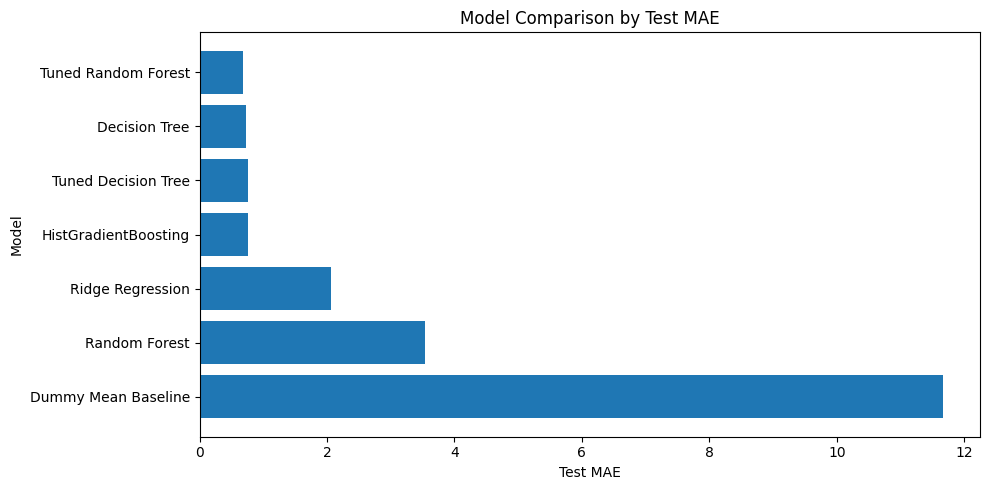

In [44]:
plot_df = test_results_df.sort_values("test_MAE", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(plot_df["model"], plot_df["test_MAE"])
plt.xlabel("Test MAE")
plt.ylabel("Model")
plt.title("Model Comparison by Test MAE")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 17. Save best model

In [46]:
best_model_name = test_results_df.iloc[0]["model"]
best_model = candidate_models[best_model_name]
print(f"Best model: {best_model_name}")

model_path = Path("models") / "best_nyc_taxi_fare_model.joblib"
joblib.dump(best_model, model_path)
print(f"Saved model to: {model_path}")

Best model: Tuned Random Forest
Saved model to: models\best_nyc_taxi_fare_model.joblib


## 18. Actual vs predicted fare plot

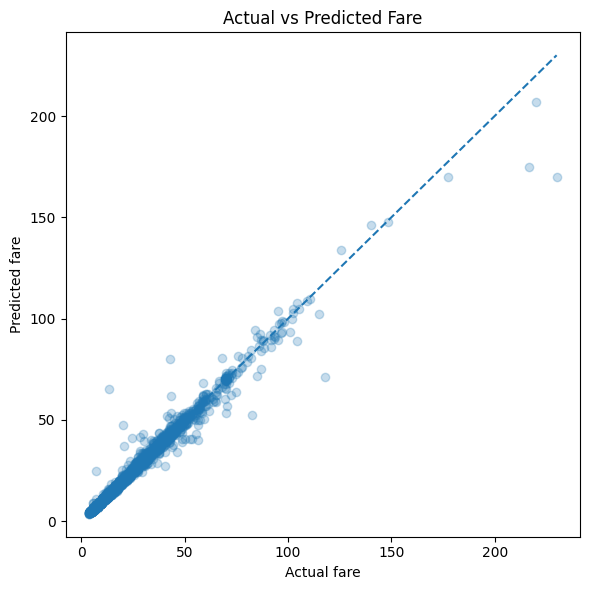

In [47]:
test_predictions = best_model.predict(X_test)

prediction_df = pd.DataFrame({
    "actual_fare": y_test.values,
    "predicted_fare": test_predictions
})

plot_sample = prediction_df.sample(n=min(5000, len(prediction_df)), random_state=RANDOM_STATE)

plt.figure(figsize=(6, 6))
plt.scatter(plot_sample["actual_fare"], plot_sample["predicted_fare"], alpha=0.25)
plt.xlabel("Actual fare")
plt.ylabel("Predicted fare")
plt.title("Actual vs Predicted Fare")

min_value = min(plot_sample["actual_fare"].min(), plot_sample["predicted_fare"].min())
max_value = max(plot_sample["actual_fare"].max(), plot_sample["predicted_fare"].max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.tight_layout()
plt.show()

## 19. Residual / error distribution

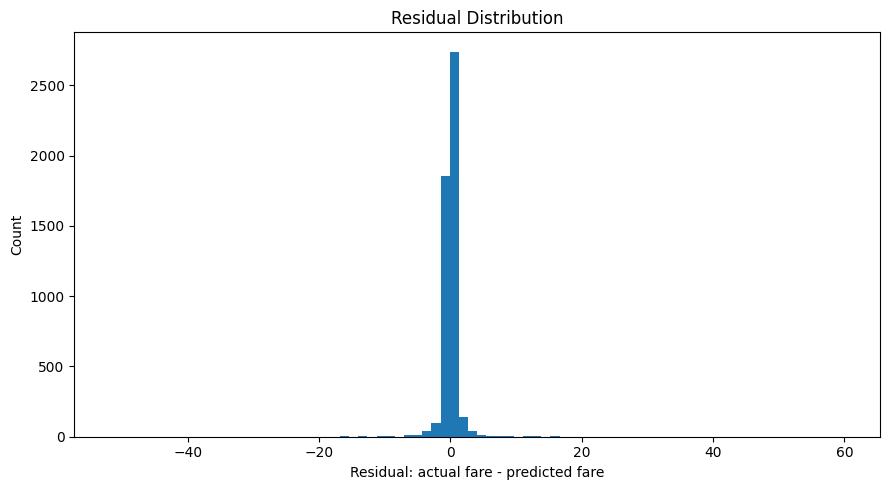

In [48]:
prediction_df["residual"] = prediction_df["actual_fare"] - prediction_df["predicted_fare"]
prediction_df["absolute_error"] = np.abs(prediction_df["residual"])

plt.figure(figsize=(9, 5))
plt.hist(prediction_df["residual"], bins=80)
plt.xlabel("Residual: actual fare - predicted fare")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.tight_layout()
plt.show()

## 20. Error by trip distance group

In [49]:
error_df = X_test.copy()
error_df["actual_fare"] = y_test.values
error_df["predicted_fare"] = test_predictions
error_df["absolute_error"] = np.abs(error_df["actual_fare"] - error_df["predicted_fare"])

error_df["distance_group"] = pd.cut(
    error_df["trip_distance"],
    bins=[0, 1, 3, 7, 15, 100],
    labels=["0-1", "1-3", "3-7", "7-15", "15+"]
)

distance_error = (
    error_df
    .groupby("distance_group", observed=True)
    .agg(
        trips=("absolute_error", "size"),
        mean_actual_fare=("actual_fare", "mean"),
        mean_predicted_fare=("predicted_fare", "mean"),
        mae=("absolute_error", "mean")
    )
    .reset_index()
)

distance_error

,distance_group,trips,mean_actual_fare,mean_predicted_fare,mae
0,0-1,1258,7.932591,7.998384,0.366700
1,1-3,2314,13.910169,13.922303,0.433299
2,3-7,742,25.725364,25.664879,0.948219
3,7-15,454,43.598238,43.469495,1.683677
4,15+,232,74.365086,73.884303,2.213360


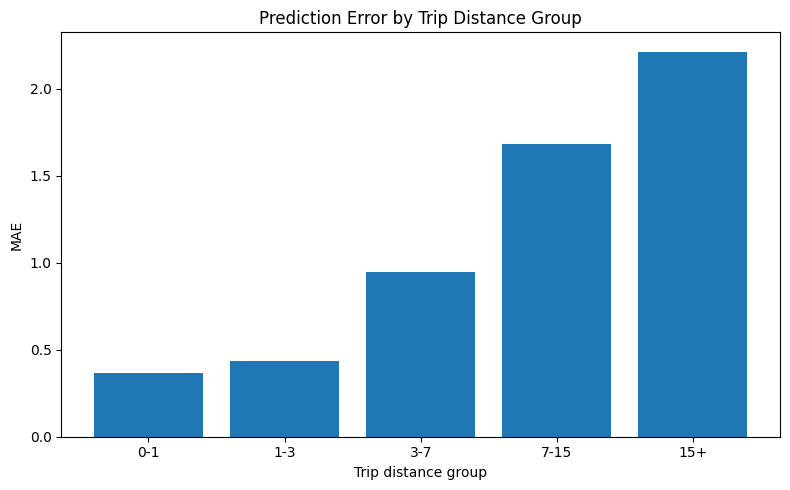

In [50]:
plt.figure(figsize=(8, 5))
plt.bar(distance_error["distance_group"].astype(str), distance_error["mae"])
plt.xlabel("Trip distance group")
plt.ylabel("MAE")
plt.title("Prediction Error by Trip Distance Group")
plt.tight_layout()
plt.show()